### **Predicting Used Car Prices**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree, metrics
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

In [3]:
### kaggle used car prices dataset
df = pd.read_csv('used_cars.csv').dropna()
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"


In [6]:
print(df.info())
print('\n',df.nunique())

<class 'pandas.core.frame.DataFrame'>
Index: 3269 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         3269 non-null   object
 1   model         3269 non-null   object
 2   model_year    3269 non-null   int64 
 3   milage        3269 non-null   object
 4   fuel_type     3269 non-null   object
 5   engine        3269 non-null   object
 6   transmission  3269 non-null   object
 7   ext_col       3269 non-null   object
 8   int_col       3269 non-null   object
 9   accident      3269 non-null   object
 10  clean_title   3269 non-null   object
 11  price         3269 non-null   object
dtypes: int64(1), object(11)
memory usage: 332.0+ KB
None

 brand             52
model           1614
model_year        34
milage          2194
fuel_type          7
engine           963
transmission      32
ext_col          120
int_col           74
accident           2
clean_title        1
price           120

In [12]:
df['mileage'] = df['milage'].str.replace(r'[\$, mi.]', '', regex=True).astype(int)
df['sale_price'] = df['price'].str.replace(r'[\$, $]', '', regex=True).astype(int)
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,mileage,sale_price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300",51000,10300
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005",34742,38005
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500",88900,15500
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000",84000,31000
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300",242000,7300


#### **Regression:**

In [13]:
### inputs
X = df[['model_year', 'mileage']]

### output
y = df['sale_price']

### train regression tree
tree = DecisionTreeRegressor(
    max_depth=2,
    random_state=0
)

tree.fit(X, y)

DecisionTreeRegressor(max_depth=2, random_state=0)

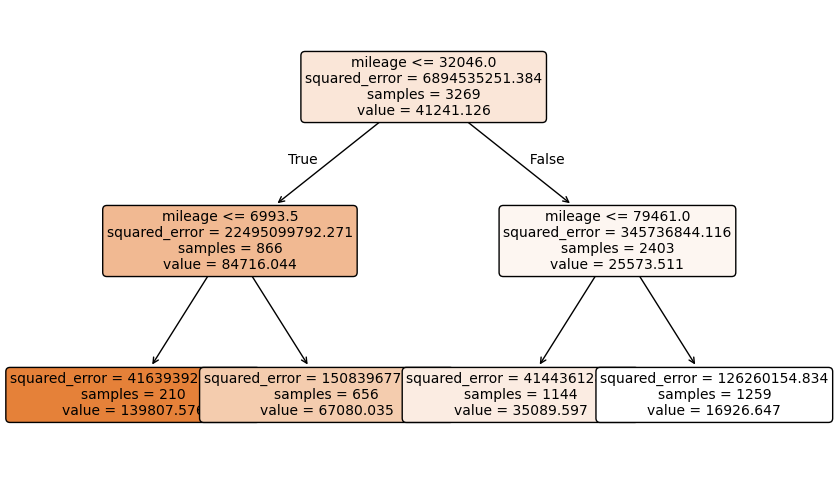

In [14]:
plt.figure(figsize=(10,6))

plot_tree(
    tree,
    feature_names=['model_year', 'mileage'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()